### Parameters

- In the context of deep learning and LLM's parameters refers to the trainable weights of the model.

- The optimization of these weights allows the model to learn from the training data.

<img src="images/Overview.png" width=600>

In [56]:
GPT_CONFIG_124M = {
    "vocab_size": 50257, # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768, # Embedding dimension
    "n_heads": 12, # Number of attention heads
    "n_layers": 12, # Number of layers
    "drop_rate": 0.1, # Dropout rate
    "qkv_bias": False # Query-Key-Value bias
}

<img src="images/Config.png" width=600>

<img src="images/CompleteStructure.png" width="600">

In [57]:
import torch
import torch.nn as nn

# This is dummy code only there to show how a real one would look like, these return what is sent to them.

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg)
            for _ in range(cfg["n_layers"])]
        )
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
    def forward(self, x):
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
    def forward(self, x):
        return x

<img src="images/Overview2.png" width=700>

In [58]:
from tiktokenizer import TikTokenizer
import torch

tokenizer = TikTokenizer.load("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))

batch = torch.stack(batch, 0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [59]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print(logits.shape)
print(logits)

torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


### Normalizing activations

- Makes the values in the vector have a variance of 1 and avg of 0. 
- Helps in dealing with vanishing gradients and exploding gradients.
- Makes training stable and convergence faster.

In [60]:
torch.manual_seed(123)
batch_example = torch.randn(2,5)
layer = nn.Sequential(nn.Linear(5,6), nn.ReLU()) # ReLU is a non linear layer, which will turn -ve values to 0
out = layer(batch_example)
print(batch_example)
print(out)

tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])
tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [61]:
# before normalizing the mean and std are

mean = out.mean(dim=-1, keepdim=True) # dim is the dimention on which we want to perform the operation here dim is -1(last/column wise) in (1,'1')
std = out.var(dim=-1, keepdim=True)

print(mean)
print(std)

tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [62]:
# Normalization

out_norm = (out - mean) / torch.sqrt(std)
mean = out_norm.mean(dim=-1, keepdim=True)
std = out_norm.var(dim=-1, keepdim=True)

print(mean)
print(std)

tensor([[-5.9605e-08],
        [ 1.9868e-08]], grad_fn=<MeanBackward1>)
tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [63]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    
    def forward(self, x: torch.Tensor):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False) # while calculating the var with unbaised True denominator will be n-1 otherwise n
        norm_x = (x - mean) / torch.sqrt(var + self.eps)

        return self.scale * norm_x + self.shift

- scale and shift are two trainable parameters which the model uses if shifting and scaling helps in better pridiction capability.

In [64]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, keepdim=True, unbiased=False)
print(mean)
print(var)

tensor([[-2.9802e-08],
        [ 0.0000e+00]], grad_fn=<MeanBackward1>)
tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


### GELU activation functions

- GELU and SwiGLU are more complex and smooth activation functions incorporating Gaussian and sigmoid-gated linear units, respectively.

- They offer improved performance for deep learning models, unlike the simpler ReLU.

- GELU (Gaussian error linear unit) and SwiGLU (Swish-gated linear unit).

<img src="images/GELU.png" width=600>

In [65]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(1/torch.pi)) * (x + 0.044715 * torch.pow(x, 3))))
    

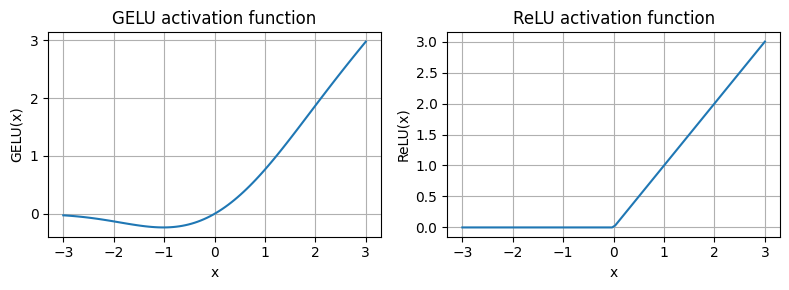

In [66]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
    plt.tight_layout()
plt.show()

GELU is smoother

In [68]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], cfg["emb_dim"] * 4),
            GELU(),
            nn.Linear(cfg["emb_dim"] * 4, cfg["emb_dim"])
        )

    def forward(self, x):
        return self.layers(x)

<img src="images/Manipulation.png" width=500>

In [69]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


- The feed forward module expands the embedding dimention of the input vector by using the first linear layer.

- The last linear layer contracts the higher dimentioned embedding vector back to the normal output vector size.

- Such design helps for exploring richer representation space.

### Redsidual/Shortcut/Skip Connections

- They were proposed for deep networks in computer vision to handle vanishing gradients.

- **Vanishing Gradients:** When gradients become progressively smaller when they are propagated backward through the layers, which makes it difficult for the starting/earlier layers to learn.

- It involves adding input of a layer to its output.

<img src="images/Residual.png" width=600>

In [78]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU()),
        ])

    def forward(self, x):
        for layer in self.layers:
            output = layer(x)
            if self.use_shortcut and x.shape == output.shape: # Addition possible only when they are of the same shape. So this wont be done on first and last layers(probably)
                x = x + output
            else:
                x = output
        return x

In [84]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([1., 0., -1.])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
layer_sizes, use_shortcut=False)

In [85]:
def print_gradient(model, x):
    output = model(x)
    target = torch.tensor([0.]) # only for example

    loss = nn.MSELoss()
    loss = loss(output, target)

    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [86]:
print_gradient(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.0001824068749556318
layers.1.0.weight has gradient mean of 0.00010869288234971464
layers.2.0.weight has gradient mean of 0.0005952615756541491
layers.3.0.weight has gradient mean of 0.0013020015321671963
layers.4.0.weight has gradient mean of 0.004566739778965712


In [87]:
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)
print_gradient(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.005687253549695015
layers.1.0.weight has gradient mean of 0.017875155434012413
layers.2.0.weight has gradient mean of 0.013760489411652088
layers.3.0.weight has gradient mean of 0.01731177419424057
layers.4.0.weight has gradient mean of 0.09019304066896439


As we can see the gradient is not as small as the above one in the earlier layers, ensuring better training.